# Plot multi-lead predictions for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import sys

sys.path.append("..")

import importlib as imp

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow

import experiment_settings
import mahalanobis
from build_data import build_hurricane_data

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "02 September 2022"

silence_tensorflow()
tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on

DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"

In [3]:
mpl.rcParams["figure.facecolor"] = "white"
# mpl.rcParams['figure.dpi'] = 300
# mpl.rcParams['savefig.dpi'] = 300
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

In [4]:
EXP_NAME_VEC = {"bivariate_normal_101_EPCP24",
                "bivariate_normal_102_EPCP48",
                "bivariate_normal_103_EPCP72",
                "bivariate_normal_104_EPCP96",
                "bivariate_normal_105_EPCP120",
                }
RNG_SEED = 123
TESTING_YEAR = 2018

In [5]:
# GET PREDICTIONS
pred_dict = dict()

for exp_name in EXP_NAME_VEC:

    print(exp_name)
    settings = experiment_settings.get_settings(exp_name)

    network_seed = RNG_SEED
    settings["rng_seed"] = RNG_SEED
    settings["years_test"] = (TESTING_YEAR,)
    (
        data_summary,
        x_train,
        onehot_train,
        x_val,
        onehot_val,
        x_test,
        onehot_test,
        x_valtest,
        onehot_valtest,
        df_train,
        df_val,
        df_test,
        df_valtest,
    ) = build_hurricane_data(DATA_PATH, settings, verbose=0)

    # load the model
    model_name = (
        exp_name
        + "_"
        + str(TESTING_YEAR)
        + "_"
        + settings["uncertainty_type"]
        + "_"
        + f"network_seed_{network_seed}_rng_seed_{settings['rng_seed']}"
    )
    model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)

    # make dictionary of the predictions
    pred_dict_lead = {"exp_name": exp_name,
                      "testing_year": TESTING_YEAR,
                      }

    # copy dataframe and fill in the predictions
    df_pred_train = df_train.copy()
    df_pred_valtest = df_valtest.copy()
    df_pred_test = df_test.copy()

    df_pred_train[["mu_u","mu_v","sigma_u","sigma_v","rho"]] = model.predict(x_train)
    df_pred_valtest[["mu_u","mu_v","sigma_u","sigma_v","rho"]] = model.predict(x_valtest)
    df_pred_test[["mu_u","mu_v","sigma_u","sigma_v","rho"]] = model.predict(x_test)

    pred_dict_lead.update({"df_pred_train": df_pred_train,
                            "df_pred_valtest": df_pred_valtest,
                            "df_pred_test": df_pred_test,
                            })
    # update master prediction dictionary
    pred_dict[exp_name] = pred_dict_lead

bivariate_normal_101_EPCP24
bivariate_normal_102_EPCP48
bivariate_normal_104_EPCP96
bivariate_normal_103_EPCP72
bivariate_normal_105_EPCP120


In [9]:
pred_dict["bivariate_normal_102_EPCP48"]["df_pred_test"]

,ATCF,Name,year,time,ftime(hr),VMAX0,NCI,OBDV,DSDV,LGDV,...,AVDY,EMDY,EGDY,HWDY,LATC,mu_u,mu_v,sigma_u,sigma_v,rho
0,EP17,OLIVIA,2018,90518,48,85.0,4,21.5,-0.5,-6.5,...,-41.7,25.0,58.3,-41.7,20.5,-15.921105,-4.401993,61.114346,57.169640,0.261916
1,EP16,NORMAN,2018,83018,48,130.0,4,-10.5,-12.5,-4.5,...,58.3,-19.4,25.0,-63.9,16.3,-8.605922,15.757475,60.037621,64.311821,0.292400
2,EP11,ILEANA,2018,80500,48,25.0,3,10.7,-0.3,-9.3,...,0.0,33.3,0.0,-33.3,16.5,20.592548,44.179840,168.083374,135.883911,0.103859
3,EP15,MIRIAM,2018,82912,48,60.0,4,13.0,2.0,1.0,...,-108.3,47.2,2.8,58.3,17.9,-65.641670,47.447155,88.648987,87.105354,0.543407
4,EP16,NORMAN,2018,90612,48,100.0,4,2.0,-9.0,-1.0,...,-58.3,41.7,-36.1,52.8,24.5,-10.615849,40.231144,104.886040,104.436287,0.413450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,EP17,OLIVIA,2018,90412,48,90.0,4,15.2,-4.8,-8.8,...,-19.4,-8.3,2.8,25.0,18.7,-6.226092,-17.656187,58.176727,52.290859,0.203580
387,EP15,MIRIAM,2018,83100,48,75.0,4,0.8,-1.2,-3.2,...,-5.6,-27.8,38.9,-5.6,23.4,-42.203064,16.208717,71.883606,70.229866,0.413770
388,CP01,WALAKA,2018,100406,48,110.0,4,-8.0,-4.0,-12.0,...,11.1,-133.3,-222.2,344.4,34.3,86.824127,1.114456,96.568825,95.288910,-0.236702
389,EP14,LANE,2018,82618,48,30.0,4,5.0,0.0,-6.0,...,47.2,47.2,-19.4,-75.0,19.9,-14.641778,-8.174433,119.122925,97.288033,0.306635


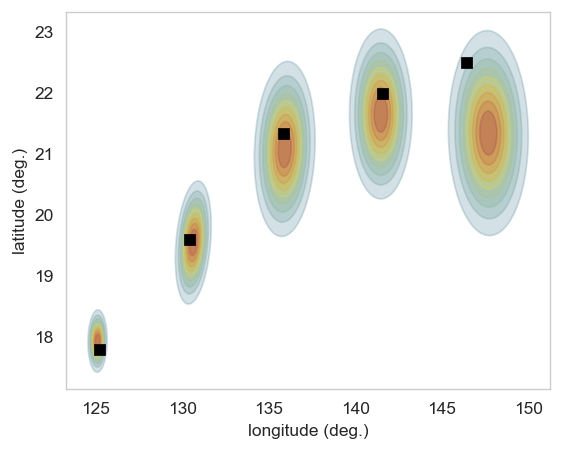

In [86]:
storm_name = "OLIVIA"
pred_time = 90506
KM_TO_DEG = 1./111


imp.reload(mahalanobis)
import cmasher as cmr
COLOR = cmr.take_cmap_colors("cmr.pride", 9, cmap_range=(0.2, 0.8), return_fmt="hex")
plt.figure(figsize=(5,4), dpi=125)

for exp_name in EXP_NAME_VEC:

    df_pred = pred_dict[exp_name]["df_pred_test"]
    df = df_pred.loc[(df_pred["Name"]==storm_name) & (df_pred["time"]==pred_time)]
    # display(df[["Name", "time", "ftime(hr)", "OBDX", "OBDY", "mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]])

    mahalanobis.plot_ring(
        df["LONC"].values - KM_TO_DEG*df["mu_u"].values,
        df["LATC"].values - KM_TO_DEG*df["mu_v"].values,
        .008*df["sigma_u"].values,
        .008*df["sigma_v"].values,
        df["rho"].values,
        besttrack_u=df["LONC"].values - KM_TO_DEG*df["OBDX"].values,
        besttrack_v=df["LATC"].values - KM_TO_DEG*df["OBDY"].values,
        colors=COLOR,
    )

plt.xlabel('longitude (deg.)')
plt.ylabel('latitude (deg.)')
# plt.ylim(15,25)

plt.show()

In [51]:
df["mu_u"]

154    8.807323
Name: mu_u, dtype: float32

In [8]:
error('here')

NameError: name 'error' is not defined

# Plot Results

In [ ]:
N_COLORS = 50
colors = ("#D95980", "#284E60", "#284E60", "#C3B1E1", "#351F27", "#A9C961")

### for white background...
plt.rc("text", usetex=True)
plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Avant Garde"]})
plt.rc("savefig", facecolor="white")
plt.rc("axes", facecolor="white")
plt.rc("axes", labelcolor="dimgrey")
plt.rc("axes", labelcolor="dimgrey")
plt.rc("xtick", color="dimgrey")
plt.rc("ytick", color="dimgrey")
################################
################################
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(("outward", 5))
        else:
            spine.set_color("none")
    if "left" in spines:
        ax.yaxis.set_ticks_position("left")
    else:
        ax.yaxis.set_ticks([])
    if "bottom" in spines:
        ax.xaxis.set_ticks_position("bottom")
    else:
        ax.xaxis.set_ticks([])


def format_spines(ax):
    adjust_spines(ax, ["left", "bottom"])
    ax.spines["top"].set_color("none")
    ax.spines["right"].set_color("none")
    ax.spines["left"].set_color("dimgrey")
    ax.spines["bottom"].set_color("dimgrey")
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params("both", length=4, width=2, which="major", color="dimgrey")


#     ax.yaxis.grid(zorder=1,color='dimgrey',alpha=0.35)

In [ ]:
def get_storm_details(df, isample):
    storm = df.iloc[isample]
    storm_name = storm["Name"]
    storm_ftime = storm["ftime(hr)"]
    storm_month = str(storm["time"])[:-4]
    storm_day = str(storm["time"])[-4:-2]
    storm_hour = str(storm["time"])[-2:]
    storm_year = storm["year"]

    details = (
        storm_name
        + " "
        + str(storm_year)
        + "-"
        + str(storm_month)
        + "-"
        + str(storm_day)
        + " "
        + str(storm_hour)
        + "00 @"
        + str(storm_ftime)
        + "hr"
    )

    return details

In [ ]:
imp.reload(mahalanobis)
import cmasher as cmr

COLOR = cmr.take_cmap_colors("cmr.pride", 9, cmap_range=(0.2, 0.8), return_fmt="hex")

sample_plot = 265
mval = 200
inc = 2

y_pred_test = pred_dict["bivariate_normal_101_EPCP24"]["y_pred_test"]

details = get_storm_details(df_test, sample_plot)
mu_u, mu_v, sigma_u, sigma_v, rho = (
    y_pred_test[sample_plot, 0],
    y_pred_test[sample_plot, 1],
    y_pred_test[sample_plot, 2],
    y_pred_test[sample_plot, 3],
    y_pred_test[sample_plot, 4],
)

plt.figure(figsize=(5, 5), dpi=150)
mahalanobis.plot_cdf(
    mu_u,
    mu_v,
    sigma_u,
    sigma_v,
    rho,
    besttrack_u=onehot_test[sample_plot, 0],
    besttrack_v=onehot_test[sample_plot, 1],
    colors=COLOR,
)
plt.legend()
cdf_val = mahalanobis.compute_cdf(
    mu_u,
    mu_v,
    sigma_u,
    sigma_v,
    rho,
    onehot_test[sample_plot, 0],
    onehot_test[sample_plot, 1],
)

plt.axis("equal")
plt.yticks(
    np.arange(-300, 500, 100),
    np.arange(-300, 500, 100),
)
plt.xticks(
    np.arange(-300, 500, 100),
    np.arange(-300, 500, 100),
)
plt.xlim(-350, 350)
plt.ylim(-350, 350)
plt.text(-325, 290, details + "\nF(x) = " + str(cdf_val.round(2)))
plt.xlabel("latitude deviation from consensus (km)")
plt.ylabel("longitude deviation from consensus (km)")

format_spines(plt.gca())
plt.show()